# TwoTank — Stage 4 — Safe Online Adaptation (Barrier vs. PSF)

Compare barrier-safe adaptation with the configured baselines.


## 1. Set up the system and load the stage config

Load dependencies and configuration.


In [1]:
"""Boilerplate: make the in-repo `sdpc` package importable and resolve this system."""
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_p = Path.cwd()
while not (_p / "src" / "sdpc").exists():
    _p = _p.parent
sys.path.insert(0, str(_p / "src"))

import torch
from sdpc.config import load_config
from sdpc.registry import make_system

SYSTEM = "twotank"
device = torch.device("cpu")
system = make_system(SYSTEM, device=device)
CONFIGS = Path.cwd().parent / "configs"
RESULTS = Path.cwd().parent / "results"

print(f"System        : {SYSTEM}")
print(f"State dim nx  : {system.nx}")
print(f"Control dim nu: {system.nu}")
print(f"Sample time ts: {system.ts}")
print(f"Input bounds  : [{system.umin}, {system.umax}]")
print(f"State bounds  : [{system.xmin}, {system.xmax}]")
print(f"Discrete model: {system.is_discrete}")


System        : twotank
State dim nx  : 2
Control dim nu: 2
Sample time ts: 1.0
Input bounds  : [0.0, 1.0]
State bounds  : [0.0, 1.0]
Discrete model: False


In [2]:
cfg = load_config(CONFIGS / 'safe.yaml')
print('Resolved safe-adaptation config:')
for k, v in cfg.items():
    if not k.startswith('_'):
        print(f'  {k}: {v}')

Resolved safe-adaptation config:
  seed: 0
  nsteps: 1500
  action_scale: 1.0
  xmin: 0.2
  xmax: 0.8
  initial_fraction_range: [0.2, 0.7]
  reference: {'kind': 'equal', 'relative_to_bounds': True, 'levels': [[0.8, 0.8], [0.25, 0.25], [0.45, 0.45], [0.8, 0.8], [0.35, 0.35]]}
  perturbation: {'c1': 0.14, 'c2': 0.03}
  weights: {'Q_con_x': 50.0, 'Q_con_du': 1.0}
  bands: {'box': 0.06, 'du': 0.0}
  du_max: 1.0
  safe: {'horizon': 20, 'gamma_ref': 2.0, 'gamma_safe': 0.4, 'clip_update': 1.0, 'safety_grad_max_norm': 1.0, 'max_safety_iters': 50, 'barrier_kind': 'squared_hinge', 'ref_backend': 'symbolic', 'safety_backend': 'symbolic', 'action_gradient_mode': 'straight_through', 'integration_method': 'rk4', 'adaptive_gamma': True, 'gamma_ref_min': 2.0, 'gamma_ref_max': 5.0, 'gamma_err_scale': 0.1}
  psf: {'horizon': 20, 'gamma_ref': 2.0, 'clip_update': 1.0, 'action_scale': 1.0, 'action_gradient_mode': 'straight_through', 'integration_method': 'rk4', 'adaptive_gamma': False, 'buffers': {'box': 0

## 2. Load the trained policy and build the safety specification

Restore the required checkpoints.


In [3]:
from sdpc.sindy import load_model

from sdpc.io import find_policy_checkpoint
policy_path = find_policy_checkpoint(RESULTS, cfg)
policy = load_model(policy_path, device=device)

plant = system.perturbed_plant(cfg)
spec = system.safety_specs(cfg)
exact_sindy = system.perturbed_sindy_model(cfg)

print('Safety constraints:', [c.name for c in spec.state_constraints])
print('Control-rate limit :', spec.control_rate.du_max if spec.control_rate else None)

Safety constraints: ['x0_min', 'x0_max', 'x1_min', 'x1_max']
Control-rate limit : 1.0


## 3. Sample a deployment scenario

Create the matched test scenario.


In [4]:
from sdpc.eval import sample_scenario

data = sample_scenario(system, cfg, cfg.get('seed', 0), device)
print('Initial state:', data['xn'][0, 0].tolist())
print('Final reference:', data['r'][0, -1].tolist())
print('Horizon length (steps):', data['r'].shape[1] - 1)

Initial state: [0.4688769578933716, 0.5504665374755859]
Final reference: [0.4100000262260437, 0.4100000262260437]
Horizon length (steps): 1500


## 3b. Choose any number of reference points

Configure the reference signal.


In [5]:
switch_steps = (data['r'][0, 1:] != data['r'][0, :-1]).any(dim=1).nonzero().flatten() + 1
segment_starts = torch.cat([torch.zeros(1, dtype=torch.long, device=device), switch_steps])
print('Configured references:', data['r'][0, segment_starts].tolist())
print('Reference switch steps:', switch_steps.tolist())

Configured references: [[0.6800000071525574, 0.6800000071525574], [0.3500000238418579, 0.3500000238418579], [0.4700000286102295, 0.4700000286102295], [0.6800000071525574, 0.6800000071525574], [0.4100000262260437, 0.4100000262260437]]
Reference switch steps: [301, 601, 901, 1201]


## 4. Baseline: the frozen policy on the perturbed (noisy) plant

Create the deployment model.


In [6]:
import copy
from sdpc.eval import rollout_closed_loop

res_frozen = rollout_closed_loop(
    copy.deepcopy(policy), plant, data,
    umin=system.umin, umax=system.umax,
    action_scale=cfg.get('action_scale', 1.0),
)
frozen_margins = spec.min_margins(res_frozen['x_traj'])
final_err = (data['r'][0, -1] - res_frozen['x_traj'][0, -1]).norm().item()
print(f'Frozen policy — final tracking error: {final_err:.4f}')
print('Frozen policy — worst-case margins over the whole rollout:')
for name, m in frozen_margins.items():
    flag = ' <-- VIOLATED' if m < 0 else ''
    print(f'  {name}: {m:.4f}{flag}')

Frozen policy — final tracking error: 0.1290
Frozen policy — worst-case margins over the whole rollout:
  x0_min: 0.0253
  x0_max: -0.0502 <-- VIOLATED
  x1_min: 0.2419
  x1_max: 0.0207


## 5. Unconstrained adaptation (no safety) on this scenario

Run Stage 3's law here too, so we have a direct comparison against the same perturbed plant and scenario.

In [7]:
from sdpc.adaptation import UnconstrainedAdaptationConfig, run_unconstrained_adaptation

# reuse only the fields UnconstrainedAdaptationConfig understands (drop safe-only keys
# like 'horizon' / 'gamma_safe' / 'barrier_kind' if 'unconstrained' isn't configured)
_unc_fields = set(UnconstrainedAdaptationConfig.__dataclass_fields__)
_raw = cfg.get('unconstrained', cfg.get('safe', {}))
ucfg = UnconstrainedAdaptationConfig(**{k: v for k, v in _raw.items() if k in _unc_fields})
res_unsafe = run_unconstrained_adaptation(
    copy.deepcopy(policy), plant, data, ucfg,
    umin=system.umin, umax=system.umax,
    derivative_model=exact_sindy, system=system,
)
unsafe_margins = spec.min_margins(res_unsafe['x_traj'])
print('Unconstrained adaptation — worst-case margins over the whole rollout:')
for name, m in unsafe_margins.items():
    flag = ' <-- VIOLATED' if m < 0 else ''
    print(f'  {name}: {m:.4f}{flag}')

Unconstrained adaptation — worst-case margins over the whole rollout:
  x0_min: -0.0459 <-- VIOLATED
  x0_max: -0.0123 <-- VIOLATED
  x1_min: 0.1502
  x1_max: 0.1094


## 6. Run barrier-augmented safe adaptation (Algorithm 2)

Run predictive safety adaptation.


In [8]:
from sdpc.adaptation import SafeAdaptationConfig, run_safe_adaptation
import time

adaptation_cell_t0 = time.perf_counter()
scfg = SafeAdaptationConfig(**cfg.get('safe', {}))
print('Safe-adaptation settings:', scfg)

res = run_safe_adaptation(
    copy.deepcopy(policy), plant, data, spec, scfg,
    umin=system.umin, umax=system.umax,
    derivative_model=exact_sindy, system=system,
)
adaptation_cell_wall = time.perf_counter() - adaptation_cell_t0

at = res['timing']
n_online = len(res['logs'])
print('\nSafe-adaptation timing breakdown')
print(f"  {'cell wall total':32s} {adaptation_cell_wall:9.4f} s")
print(f"  {'runner total':32s} {at['total_s']:9.4f} s")
for label, key in [
    ('setup total', 'setup_total_s'),
    ('  prediction callable setup', 'prediction_setup_s'),
    ('  reference Jacobian creation', 'reference_jacobian_setup_s'),
    ('  safety Jacobian creation', 'safety_jacobian_setup_s'),
    ('  other setup', 'setup_overhead_s'),
    ('online total', 'online_total_s'),
    ('  reference updates', 'reference_update_total_s'),
    ('    reference derivatives', 'reference_gradient_total_s'),
    ('    coefficient updates', 'reference_apply_total_s'),
    ('    reference overhead', 'reference_overhead_s'),
    ('  safety rollout total', 'safety_rollout_total_s'),
    ('    predictive dynamics', 'safety_prediction_total_s'),
    ('    safety-loss evaluation', 'safety_loss_total_s'),
    ('    rollout overhead', 'safety_rollout_overhead_s'),
    ('  safety gradient total', 'safety_gradient_total_s'),
    ('    safety derivatives', 'safety_derivative_total_s'),
    ('    coefficient updates', 'safety_update_total_s'),
    ('    gradient overhead', 'safety_gradient_overhead_s'),
    ('  applied policy + plant steps', 'plant_step_total_s'),
    ('  safety diagnostics', 'diagnostics_total_s'),
    ('  online loop overhead', 'online_overhead_s'),
]:
    value = at[key]
    rate = '' if 'setup' in key else f'  ({1e3 * value / n_online:.4f} ms/step)'
    print(f'  {label:32s} {value:9.4f} s{rate}')

Safe-adaptation settings: SafeAdaptationConfig(horizon=20, gamma_ref=2.0, gamma_safe=0.4, clip_update=1.0, safety_grad_max_norm=1.0, safety_gain=1.0, max_safety_iters=50, barrier_kind='squared_hinge', barrier_eps=1e-06, safety_loss_tol=1e-10, action_scale=1.0, integration_method='rk4', ref_backend='symbolic', safety_backend='symbolic', action_gradient_mode='straight_through', adaptive_gamma=True, gamma_ref_min=2.0, gamma_ref_max=5.0, gamma_err_scale=0.1, verbose=False)

Safe-adaptation timing breakdown
  cell wall total                     9.1184 s
  runner total                        9.1162 s
  setup total                         0.0007 s
    prediction callable setup         0.0000 s
    reference Jacobian creation       0.0001 s
    safety Jacobian creation          0.0000 s
    other setup                       0.0006 s
  online total                        9.1154 s  (6.0770 ms/step)
    reference updates                 1.7164 s  (1.1443 ms/step)
      reference derivatives      

In [9]:
# def safety_work(res):
#     n_steps = len(res["logs"])
#     n_iters = sum(row["safety_iters"] for row in res["logs"])
#     n_rollouts = n_steps + n_iters
#
#     t = res["timing"]
#     return {
#         "steps": n_steps,
#         "safety_iters": n_iters,
#         "safety_rollouts": n_rollouts,
#         "rollout_ms_each": 1e3 * t["safety_rollout_total_s"] / n_rollouts,
#         "gradient_ms_each": (
#             1e3 * t["safety_gradient_total_s"] / max(n_iters, 1)
#         ),
#         "safety_ms_per_step": (
#             1e3 * (
#                 t["safety_rollout_total_s"]
#                 + t["safety_gradient_total_s"]
#             ) / n_steps
#         ),
#     }
#
# print("symbolic:", safety_work(res))
# print("autograd:", safety_work(res))


## 7. Predictive Safety Filter baseline (Algorithm 3)

Run the safety-filter baseline.


In [10]:
from sdpc.adaptation import PSFConfig, run_psf_adaptation, casadi_available
import time

assert casadi_available(), "PSF comparison requires CasADi in the active environment"
psf_cell_t0 = time.perf_counter()
pcfg = PSFConfig(**cfg.get('psf', {}))
print('PSF settings:', pcfg)

res_psf = run_psf_adaptation(
    copy.deepcopy(policy), plant, data, spec, pcfg,
    system=system, system_cfg=cfg,
    umin=system.umin, umax=system.umax,
)
psf_cell_wall = time.perf_counter() - psf_cell_t0

pt = res_psf['timing']
n_online = len(res_psf['logs'])
print('\nPSF timing breakdown')
print(f"  {'cell wall total':32s} {psf_cell_wall:9.4f} s")
print(f"  {'runner total':32s} {pt['total_s']:9.4f} s")
for label, key in [
    ('setup total', 'setup_total_s'),
    ('  CasADi solver creation', 'solver_setup_s'),
    ('  other setup', 'setup_overhead_s'),
    ('online total', 'online_total_s'),
    ('  reference updates', 'reference_update_total_s'),
    ('    reference derivatives', 'reference_gradient_total_s'),
    ('    coefficient updates', 'reference_apply_total_s'),
    ('    reference overhead', 'reference_overhead_s'),
    ('  full filter call', 'filter_wrapper_total_s'),
    ('    parameter/guess preparation', 'filter_prepare_total_s'),
    ('    initial trajectory guesses', 'filter_initialization_total_s'),
    ('    IPOPT solver', 'filter_solver_total_s'),
    ('    solution extraction', 'filter_extraction_total_s'),
    ('    unattributed call overhead', 'filter_unattributed_total_s'),
    ('    outer timing overhead', 'filter_outer_overhead_s'),
    ('  applied plant steps', 'plant_step_total_s'),
    ('  safety diagnostics', 'diagnostics_total_s'),
    ('  online loop overhead', 'online_overhead_s'),
]:
    value = pt[key]
    rate = '' if 'setup' in key else f'  ({1e3 * value / n_online:.4f} ms/step)'
    print(f'  {label:32s} {value:9.4f} s{rate}')
print(f"Realized violations     : {sum(row['realized_violation'] for row in res_psf['logs'])}")


PSF settings: PSFConfig(horizon=20, gamma_ref=2.0, clip_update=1.0, action_scale=1.0, action_gradient_mode='straight_through', integration_method='rk4', adaptive_gamma=False, gamma_ref_min=0.01, gamma_ref_max=0.2, gamma_err_scale=0.2, default_buffer=0.0, buffers={'box': 0.06, 'du': 0.0}, tail_weight=1e-06, smooth_weight=0.001, max_iter=500, tol=1e-06, verbose=False)

PSF timing breakdown
  cell wall total                    11.0839 s
  runner total                       11.0801 s
  setup total                         0.0426 s
    CasADi solver creation            0.0418 s
    other setup                       0.0008 s
  online total                       11.0376 s  (7.3584 ms/step)
    reference updates                 1.9931 s  (1.3287 ms/step)
      reference derivatives           1.8303 s  (1.2202 ms/step)
      coefficient updates             0.1624 s  (0.1083 ms/step)
      reference overhead              0.0004 s  (0.0003 ms/step)
    full filter call                  8.3548 s  (

## 8. Per-step safety log

Inspect safety diagnostics over time.


In [11]:
print(f"{'t':>4} {'pred_safe':>10} {'iters':>6} {'barrier_loss':>13} "
      f"{'min_margin':>11} {'realized_viol':>13}")
for l in res['logs'][::max(1, len(res['logs']) // 20)]:
    print(f"{l['t']:>4} {str(l['predicted_safe']):>10} {l['safety_iters']:>6} "
          f"{l['barrier_loss']:>13.3e} {l['min_pred_margin']:>11.4f} "
          f"{str(l['realized_violation']):>13}")

n_safe = sum(l['predicted_safe'] for l in res['logs'])
n_real_viol = sum(l['realized_violation'] for l in res['logs'])
total_iters = sum(l['safety_iters'] for l in res['logs'])
print(f"\nSteps predicted-safe at commit : {n_safe} / {len(res['logs'])}")
print(f"Steps with a realized violation: {n_real_viol} / {len(res['logs'])}")
print(f"Total inner safety-gradient iters: {total_iters}")

   t  pred_safe  iters  barrier_loss  min_margin realized_viol
   1       True      1     0.000e+00      0.1013         False
  76       True      0     0.000e+00      0.1013         False
 151       True      0     0.000e+00      0.1045         False
 226       True      0     0.000e+00      0.1089         False
 301       True      0     0.000e+00      0.0752         False
 376       True      0     0.000e+00      0.1508         False
 451       True      0     0.000e+00      0.1500         False
 526       True      0     0.000e+00      0.1500         False
 601       True      0     0.000e+00      0.1500         False
 676       True      0     0.000e+00      0.2480         False
 751       True      0     0.000e+00      0.2657         False
 826       True      0     0.000e+00      0.2692         False
 901       True      0     0.000e+00      0.0618         False
 976       True      0     0.000e+00      0.1170         False
1051       True      0     0.000e+00      0.1163       

## 9. Safety-barrier evolution

Inspect safety diagnostics over time.


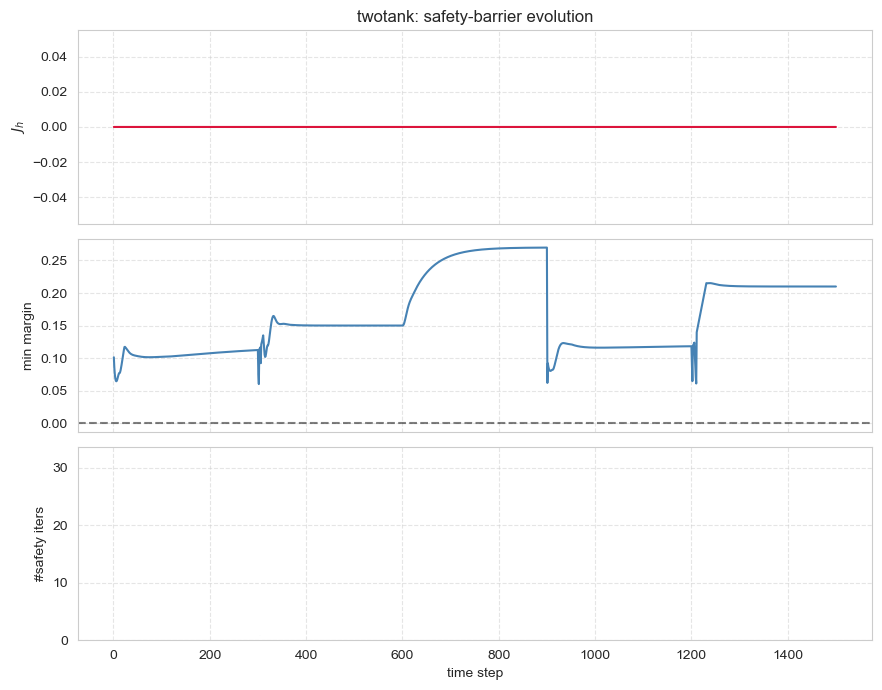

In [12]:
from sdpc.plotting import plot_barrier_evolution
import matplotlib.pyplot as plt

plot_barrier_evolution(res['logs'], title=f'{SYSTEM}: safety-barrier evolution')
plt.show()

## 10. Trajectory comparison: frozen, unconstrained, barrier, and PSF

Compare the executed trajectories.


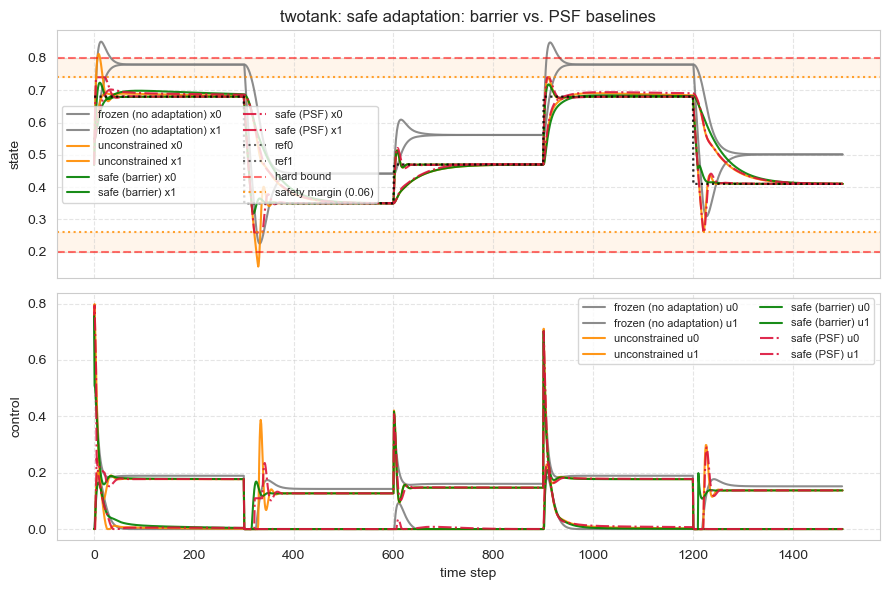

In [13]:
from sdpc.plotting import plot_states_and_controls
import matplotlib.pyplot as plt

xlo, xhi = map(float, data['state_bounds'].detach().cpu().tolist())
plot_states_and_controls(
    [
        {'x': res_frozen['x_traj'], 'u': res_frozen['u_traj'], 'label': 'frozen (no adaptation)', 'color': 'gray'},
        {'x': res_unsafe['x_traj'], 'u': res_unsafe['u_traj'], 'label': 'unconstrained', 'color': 'darkorange'},
        {'x': res['x_traj'], 'u': res['u_traj'], 'label': 'safe (barrier)', 'color': 'green'},
        {'x': res_psf['x_traj'], 'u': res_psf['u_traj'], 'label': 'safe (PSF)', 'color': 'crimson', 'linestyle': '-.'},
    ],
    r_traj=data['r'], xmin=xlo, xmax=xhi,
    state_margin=float(cfg.get('bands', {}).get('box', 0.0)),
    title=f'{SYSTEM}: safe adaptation: barrier vs. PSF baselines',
)
plt.show()

In [14]:
print(res["u_traj"][:,375:400,:])
print(res_psf["u_traj"][:,375:400,:])

tensor([[[0.1266, 0.0000],
         [0.1266, 0.0000],
         [0.1266, 0.0000],
         [0.1266, 0.0000],
         [0.1266, 0.0000],
         [0.1266, 0.0000],
         [0.1266, 0.0000],
         [0.1266, 0.0000],
         [0.1266, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000]]])
tensor([[[1.2690e-01, 9.6922e-05],
         [1.2627e-01, 1.6350e-04],
         [1.2579e-01, 1.6898e-04],
         [1.2548e-01, 1.7242e-04],
         [1.2531e-01, 1.7525e-04],
         [1.2528e-01, 1.7768e-04],
         [1.2535e-01, 1.7976e-04],
         [1.2551e-01, 1.8154e-04],
         [1.2571e-01, 1.8307e-04],
        

In [15]:
res["logs"]

[{'t': 1,
  'gamma_ref': 2.252002000808716,
  'safety_iters': 1,
  'predicted_safe': True,
  'barrier_loss': 0.0,
  'reference tracking grad:': [tensor([[0.0117],
           [0.0102],
           [0.0078],
           [0.0036]]),
   tensor([[0.0001],
           [0.0001]])],
  'safety_grads': [tensor([[-0.8349],
           [ 0.0834],
           [-0.3302],
           [-0.2569]]),
   tensor([[0.0470],
           [0.3446]])],
  'min_pred_margin': 0.10127401351928711,
  'realized_min_margin': 0.25069254636764526,
  'realized_violation': False,
  'reference_time': 0.001637666005990468,
  'reference_gradient_time': 0.001547708990983665,
  'reference_apply_time': 8.970800263341516e-05,
  'safety_rollout_time': 0.00989533300162293,
  'safety_prediction_time': 0.009493916004430503,
  'safety_loss_time': 0.00034391599183436483,
  'safety_gradient_time': 0.0026558340032352135,
  'safety_derivative_time': 0.002573582998593338,
  'safety_update_time': 8.183298632502556e-05,
  'plant_time': 0.000291999

In [16]:
res_psf["logs"]

[{'t': 1,
  'gamma_ref': 2.0,
  'track_err': 0.17816521227359772,
  'correction_norm': 0.00020635568944271654,
  'min_pred_margin': 0.06001180410385132,
  'min_pred_state_margin': 0.06001180410385132,
  'min_pred_control_rate_margin': 0.9807740449905396,
  'realized_min_margin': 0.24154043197631836,
  'realized_state_margin': 0.24154043197631836,
  'realized_control_rate_margin': 0.9986860752105713,
  'realized_violation': False,
  'reference_time': 0.017490749989519827,
  'reference_gradient_time': 0.01731558400206268,
  'reference_apply_time': 0.0001745000045048073,
  'filter_wall_time': 0.037185958004556596,
  'plant_time': 0.00029420900682453066,
  'diagnostics_time': 0.00017520900291856378,
  'step_time': 0.05521145899547264,
  'success': True,
  'status': 'Solve_Succeeded',
  'solver_iters': 12,
  'filter_time': 0.035505416002706625,
  'filter_prepare_time': 0.0003648749989224598,
  'filter_initialization_time': 0.0006240829970920458,
  'filter_extraction_time': 0.000631333998171

In [17]:
res["u_traj"][:,375:420,:]

tensor([[[0.1266, 0.0000],
         [0.1266, 0.0000],
         [0.1266, 0.0000],
         [0.1266, 0.0000],
         [0.1266, 0.0000],
         [0.1266, 0.0000],
         [0.1266, 0.0000],
         [0.1266, 0.0000],
         [0.1266, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
         [0.1267, 0.0000],
 

## 11. Tracking, safety, smoothness, and computation metrics

Report sustained final-reference stabilization, safety, smoothness, and runtime.


In [18]:
import numpy as np
import pandas as pd
from sdpc.eval import compute_metrics

method_runs = {
    'frozen': res_frozen,
    'unconstrained': res_unsafe,
    'safe_barrier': res,
    'psf': res_psf,
}

metric_cfg = cfg.get('metrics', {})
reach_tolerance = float(metric_cfg.get('reach_tolerance', 0.05))
reach_hold_steps = int(metric_cfg.get('reach_hold_steps', 5))

metric_rows = []
margin_rows = []
for method, run in method_runs.items():
    metrics = compute_metrics(
        run['x_traj'], run['u_traj'], data['r'],
        spec=spec, logs=run.get('logs'),
        reach_tolerance=reach_tolerance, reach_hold_steps=reach_hold_steps,
    )
    metric_rows.append({
        'method': method,
        'reached_final_ref': metrics['reached_reference'],
        'steps_to_stabilize': metrics['steps_to_reach'],
        'stabilization_step': metrics['final_reference_stabilization_step'],
        'tracking_mse': metrics['tracking_mse'],
        'state_violations': metrics['num_state_violations'],
        'du_violations': metrics.get('num_control_rate_violations', 0),
        'min_state_margin': metrics['min_state_margin'],
        'min_du_margin': metrics.get('min_control_rate_margin', np.nan),
        'smooth_rms_du': metrics['control_smoothness_rms'],
        'mean_du_l2': metrics['mean_du_l2'],
        'max_du_l2': metrics['max_du_l2'],
        'online_total_s': metrics.get('runtime_total_s', np.nan),
        'online_ms_per_step': 1e3 * metrics.get('runtime_per_step_s', np.nan),
        'filter_ms_per_step': 1e3 * metrics.get('filter_runtime_per_step_s', np.nan),
        'solver_setup_s': run.get('setup_time_s', np.nan),
    })
    margin_rows.append({'method': method, **spec.min_margins(run['x_traj'])})

metrics_df = pd.DataFrame(metric_rows).set_index('method')
margins_df = pd.DataFrame(margin_rows).set_index('method')
display(metrics_df.round(5))
print('Constraint-wise minimum margins (negative means violated):')
display(margins_df.round(5))


,tracking_mse,state_violations,du_violations,min_state_margin,min_du_margin,smooth_rms_du,mean_du_l2,max_du_l2,online_total_s,online_ms_per_step,filter_ms_per_step,solver_setup_s
method,,,,,,,,,,,,
frozen,0.02423,54,0,-0.05015,0.74623,0.01747,0.00220,0.50375,NaN,NaN,NaN,NaN
unconstrained,0.00458,11,0,-0.04589,0.68200,0.02086,0.00317,0.56392,2.11034,1.40689,NaN,NaN
safe_barrier,0.00492,0,0,0.07687,0.69142,0.02071,0.00249,0.55550,9.11113,6.07409,NaN,0.00071
psf,0.00459,0,0,0.06000,0.69134,0.02129,0.00284,0.55557,11.00590,7.33727,3.4576,0.04175


Constraint-wise minimum margins (negative means violated):


,x0_min,x0_max,x1_min,x1_max
method,,,,
frozen,0.02528,-0.05015,0.24193,0.02072
unconstrained,-0.04589,-0.01231,0.15019,0.10940
safe_barrier,0.11943,0.07687,0.15026,0.10165
psf,0.06000,0.06000,0.15035,0.09787


## 12. Compare the squared-hinge and relaxed-log barriers

Compare the barrier penalty shapes.


In [19]:
other_kind = 'relaxed_log' if scfg.barrier_kind == 'squared_hinge' else 'squared_hinge'
scfg_other = SafeAdaptationConfig(**{**cfg.get('safe', {}), 'barrier_kind': other_kind})
res_other = run_safe_adaptation(
    copy.deepcopy(policy), plant, data, spec, scfg_other,
    umin=system.umin, umax=system.umax,
    derivative_model=exact_sindy, system=system,
)

m1 = spec.min_margins(res['x_traj'])
m2 = spec.min_margins(res_other['x_traj'])
print(f"{'constraint':>14} {scfg.barrier_kind:>16} {other_kind:>16}")
for name in m1:
    print(f'{name:>14} {m1[name]:>16.4f} {m2[name]:>16.4f}')

ValueError: relaxed_log requires band > 0